# Deep Learning project Part B

## Background Research
The pizza reviews dataset contains short text reviews paired with numeric scores from 0 to 10. The reviews include languages other than English, which will be examined and handled during preprocessing. The task is to classify the sentiment of a review based on its text alone.

RNNs are well suited for text classification because they process tokens sequentially and maintain a hidden state that carries information across the sequence, unlike feedforward networks which treat each token independently and lose word order. Variants like LSTM and GRU address the vanishing gradient problem of the basic RNN using gating mechanisms, and bidirectional versions read the sequence in both directions. These variants will be explored and compared in the modelling section.

**Sources**

Wei, J., & Zou, K. (2019). EDA: Easy data augmentation techniques for boosting performance on text classification tasks. https://arxiv.org/abs/1901.11196

## Setup
Suppress TensorFlow info/warning logs and fix all random seeds so results are reproducible.

In [1]:
# Suppress TensorFlow logs 
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # 0=all, 1=info, 2=warning, 3=error only
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0' # silence oneDNN floating-point notice

# Suppress Python-level warnings (HDF5 legacy, deprecation, retracing, etc.)
import warnings
warnings.filterwarnings('ignore')

# Silence loggers used internally by TensorFlow and Keras
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
logging.getLogger('absl').setLevel(logging.ERROR)

In [2]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Data Exploration & Cleaning
Check the dataset structure, find any broken values and decide how to clean it.

In [3]:
df = pd.read_csv('Pizza reviews.csv')

## Before Cleaning
Look at the column types and contents to find any problems.

In [4]:
print(f'Dataset Shape: {df.shape}')
df.head(10)

Dataset Shape: (902, 4)


,Review,Score,"Are there ways for you to generate more data? Spliting up sentences, would that help?",Language
0,Disgusting.,1,NaN,English
1,Loved the sambal kick!,10,NaN,English
2,Loved the sambal kick!,0.1,NaN,English
3,Loved the sambal kick!,5,NaN,English
4,"Satay on pizza? Surprisingly worked. Tasty, un...",7,NaN,English
5,Mayo was too sweet. Didn't enjoy it at all.,3,NaN,English
6,"Spicy sambal was overwhelming for me, but the ...",6,NaN,English
7,"Crust was soggy, and the satay sauce didn’t he...",4,NaN,English
8,Super creative! Sambal slice was fiery and bol...,7,NaN,English
9,The sambal slice burned my mouth in the best w...,8,NaN,English


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 902 entries, 0 to 901
Data columns (total 4 columns):
 #   Column                                                                                 Non-Null Count  Dtype 
---  ------                                                                                 --------------  ----- 
 0   Review                                                                                 902 non-null    object
 1   Score                                                                                  900 non-null    object
 2   Are there ways for you to generate more data? Spliting up sentences, would that help?  2 non-null      object
 3   Language                                                                               902 non-null    object
dtypes: object(4)
memory usage: 28.3+ KB


Score is stored as object instead of a number which means there are non-numeric values mixed in. The third column has a very long lecturer-written name and is almost all NaN. Look at the third column first since it stands out.

In [6]:
# Look at rows where the third column has a value
df[df.iloc[:, 2].notna()]

,Review,Score,"Are there ways for you to generate more data? Spliting up sentences, would that help?",Language
22,Review,Score,Really?,Come on ...
191,Review,Score,Again??,You cannot be serious ...


The third column has values on only 2 rows, and those same 2 rows have Review and Score literally containing the strings 'Review' and 'Score'. These are header-bleed rows that need to be dropped. The third column itself is a lecturer hint and not a feature so it can also be dropped.

In [7]:
# Drop the hint column
df = df.drop(columns=[df.columns[2]])
print(df.columns.tolist())

['Review', 'Score', 'Language']


In [8]:
# Find rows where Score can't be converted to a number
numeric_scores = pd.to_numeric(df['Score'], errors='coerce')
non_numeric = df[numeric_scores.isna()]
print(f'Rows with non-numeric Score: {len(non_numeric)}')
non_numeric[['Review', 'Score']]

Rows with non-numeric Score: 5


,Review,Score
22,Review,Score
191,Review,Score
897,Ni hao,NaN
900,Diabolic,NaN
901,Jia!,???


Apart from the 2 header-bleed rows already found there are 2 rows with NaN scores and 1 row with '???' as the score. These cannot be parsed and will be dropped.

In [9]:
# Look at the range of the numeric scores
numeric_scores.describe()

count     897.000000
mean        6.556311
std        33.790550
min       -42.000000
25%         1.100000
50%         5.350000
75%         9.700000
max      1010.000000
Name: Score, dtype: float64

Scores should be on a 0 to 10 scale but the min is -42 and the max is 1010. Look at the rows outside the expected range.

In [10]:
# Rows with Score outside the expected 0 to 10 range
df[(numeric_scores < 0) | (numeric_scores > 10)][['Review', 'Score', 'Language']]

,Review,Score,Language
727,Pizza ni langsung tak sedap.,-0.5,Malay
730,Topping basi?,-0.2,Malay
732,Pizza ni buat saya sakit perut.,-0.1,Malay
742,Fusion pizza ni langsung tak sedap.,-0.3,Malay
748,Tak akan beli lagi.,-0.1,Malay
752,Fusion pizza ni buat saya sakit perut.,-0.2,Malay
769,Tak akan pesan lagi.,-0.1,Malay
784,Tak akan pesan lagi.,-0.1,Malay
799,Tak akan pesan lagi.,-0.1,Malay
814,Tak akan pesan lagi.,-0.1,Malay


The 1010 row says 'Ten out of ten, would highly recommend!' so it's clearly meant to be a 10, fix it instead of dropping. The -42 row says 'Oh itz phenomenal!' which is positive but doesn't give a specific number, so it's unclear if it should be 8, 9 or 10, drop this row since there's no reliable way to fix it. The small negative scores like -0.5 and -0.219 are kept since the review text is genuinely very negative.

In [11]:
df['Language'].value_counts()

Language
English                      492
Malay                        402
Chinese                        3
Guga                           2
Come on ...                    1
You cannot be serious ...      1
Nippon                         1
Name: count, dtype: int64

Apart from English and Malay there are joke labels (Guga, Come on..., You cannot be serious...) and a few rows in Chinese and Nippon (Japanese). Keep only English and Malay because
- They make up the bulk of the data
- They share Latin script so a shared tokenizer works for both
- Together they give nearly twice as much training data as English alone, which matters for a small dataset

In [12]:
# Count duplicates and reviews with inconsistent scores
print(f'Exact duplicate rows: {df.duplicated().sum()}')
print(f'Reviews appearing more than once: {df["Review"].duplicated().sum()}')

Exact duplicate rows: 45
Reviews appearing more than once: 102


In [13]:
# Sample of fully duplicate rows (same Review AND same Score)
print('Example of fully duplicate rows:')
df[df.duplicated(keep=False)].sort_values(['Review', 'Score']).head(6)

Example of fully duplicate rows:


,Review,Score,Language
19,"Crust was thin and crispy, just right.",6,English
30,"Crust was thin and crispy, just right.",6,English
0,Disgusting.,1,English
70,Disgusting.,1,English
15,Disgusting.,2,English
26,Disgusting.,2,English


In [14]:
# Reviews appearing with inconsistent scores (label noise, not true duplicates)
noisy = df.groupby('Review').agg(
    occurrences=('Score', 'count'),
    unique_scores=('Score', 'nunique'),
    all_scores=('Score', lambda x: sorted(x.tolist()))
).query('unique_scores > 1').sort_values('unique_scores', ascending=False)

print(f'Reviews appearing with inconsistent scores: {len(noisy)}')
print('Examples of label noise:')
noisy.head(8)

Reviews appearing with inconsistent scores: 44
Examples of label noise:


,occurrences,unique_scores,all_scores
Review,,,
Roti keras macam batu.,6,4,"[0.1, 0.2, 0.2, 0.2, 0.3, 1.5]"
Roti keras dan topping basi.,9,4,"[0, 0.1, 0.1, 0.1, 0.2, 0.2, 0.2, 0.2, 0.8]"
Love at first bite.,4,4,"[0.04, 5.72, 8.49, 8.79]"
Fusion pizza ni sangat mengecewakan.,5,3,"[0.1, 0.1, 0.15, 0.2, 0.2]"
Loved the sambal kick!,3,3,"[0.1, 10, 5]"
"The sambal slice burned my mouth in the best way. Satay chicken was tender and flavorful, perfect with the peanut sauce. Mayo could’ve been left off, honestly—it clashed with the rest. Still, the crust was crispy and the ingredients felt fresh. I'd definitely order again, especially for the satay.",5,3,"[5.91, 8, 8, 8, 9]"
Tak sedap dan tak puas hati.,5,3,"[0, 0.15, 0.15, 0.15, 0.35]"
Meh.,5,3,"[4, 4.8, 5, 5, 5]"


There are 45 fully duplicate rows (same Review and same Score) that add no information and can be dropped. There are also reviews appearing multiple times with different scores. These aren't duplicates since the labels disagree, but they are inconsistent labels (label noise).

Some of these are obviously wrong, like 'Loved the sambal kick!' having a score of 0.1 when the text is clearly positive. They're still kept on purpose since real datasets always have label noise and the model should learn to be robust to it. Manually fixing them would mean making subjective calls about what each review 'should' be scored. However, keep an additional dataset to test the dataset without the additional label noise.

## Apply Cleaning Steps
Each step is applied in order, with a shape check after each to confirm only the intended rows are removed.

In [15]:
# Drop the 2 header-bleed rows
df = df[(df['Review'] != 'Review') & (df['Score'] != 'Score')].reset_index(drop=True)
print(f'Shape: {df.shape}')

Shape: (900, 3)


In [16]:
# Drop NaN scores and the '???' score, then cast to float
df = df.dropna(subset=['Score'])
df = df[pd.to_numeric(df['Score'], errors='coerce').notna()].reset_index(drop=True)
df['Score'] = df['Score'].astype(float)
print(f'Shape: {df.shape}')

Shape: (897, 3)


In [17]:
# Fix the 1010 row to 10. Also fix its corrupted Language label.
df.loc[df['Score'] == 1010, 'Language'] = 'English'
df.loc[df['Score'] == 1010, 'Score'] = 10.0
df[df['Review'].str.contains('Ten out of ten', na=False)]

,Review,Score,Language
893,"Ten out of ten, would highly recommend!",10.0,English


In [18]:
# Drop the -42 outlier. Small negatives (-0.5, -0.219 etc.) are kept as genuinely negative reviews.
df = df[df['Score'] > -1].reset_index(drop=True)
print(f'Shape: {df.shape}')
print(f'Score range: [{df["Score"].min()}, {df["Score"].max()}]')

Shape: (896, 3)
Score range: [-0.5, 10.0]


In [19]:
# Keep only English and Malay
df = df[df['Language'].isin(['English', 'Malay'])].reset_index(drop=True)
print(f'Shape: {df.shape}')
print(df['Language'].value_counts())

Shape: (894, 3)
Language
English    492
Malay      402
Name: count, dtype: int64


In [20]:
# Drop exact duplicates, keep label-noise rows
df = df.drop_duplicates(subset=['Review', 'Score']).reset_index(drop=True)
print(f'Final shape: {df.shape}')

Final shape: (849, 3)


Keeping the noisy labels means training on a realistic representation of imperfect data and forces the model to be more robust to inconsistency. Collapsing label noise gives the model cleaner signal which helps on a small dataset. To test which works better, create a second version of the dataset where reviews appearing with inconsistent scores are collapsed to a single row, scored by the median of all their occurrences.

Median is used instead of mean since it's more robust to extreme conflicts like "Loved the sambal kick!" appearing with scores 0.1, 5.0, 10.0. Mean would give 5.03 but a single outlier could pull it more. Median consistently picks the middle ground.

Both versions (df with label noise kept and df_collapsed with it removed) will be trained and compared in the modelling section.

In [21]:
# Collapsed version: each review appears once, score is the median of its occurrences
df_collapsed = df.groupby(['Review', 'Language'], as_index=False)['Score'].median()
print(f'Original (label noise kept): {len(df)} rows')
print(f'Collapsed (label noise removed): {len(df_collapsed)} rows')

Original (label noise kept): 849 rows
Collapsed (label noise removed): 793 rows


## After Cleaning
After cleaning the dataset has 849 rows: 474 English and 375 Malay reviews. Look at the score distribution, review length, sentiment class balance, top words per class, and sentence counts to understand the cleaned data.

In [22]:
df.head()

,Review,Score,Language
0,Disgusting.,1.0,English
1,Loved the sambal kick!,10.0,English
2,Loved the sambal kick!,0.1,English
3,Loved the sambal kick!,5.0,English
4,"Satay on pizza? Surprisingly worked. Tasty, un...",7.0,English


### Score Distribution
The score distribution has a cluster of negative reviews near 0 and a larger cluster of positive reviews near 9-10, with fewer reviews in the middle. English and Malay have very similar distributions so they can be modelled together.

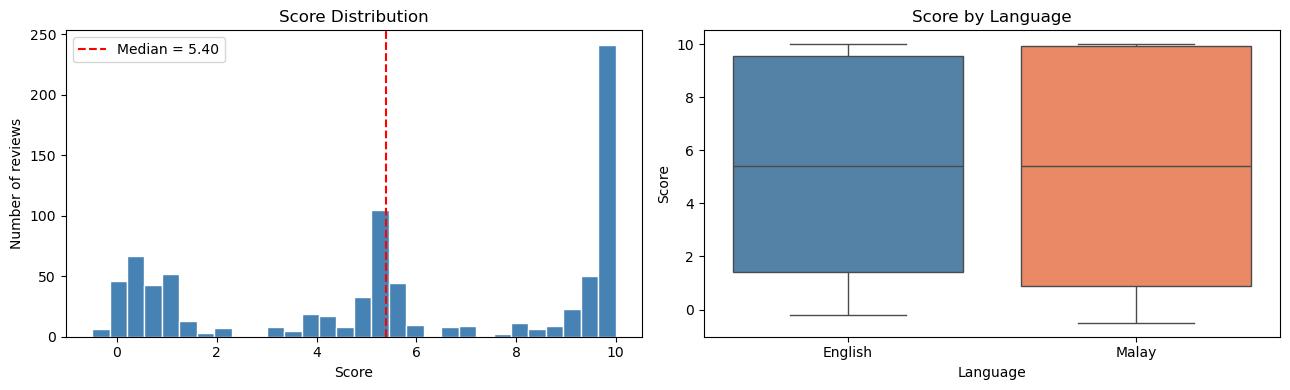

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Overall score histogram
axes[0].hist(df['Score'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Number of reviews')
axes[0].set_title('Score Distribution')
axes[0].axvline(df['Score'].median(), color='red', linestyle='--',
                label=f'Median = {df["Score"].median():.2f}')
axes[0].legend()

# Score by language
sns.boxplot(data=df, x='Language', y='Score', hue='Language', ax=axes[1],
            palette={'English':'steelblue', 'Malay':'coral'}, legend=False)
axes[1].set_title('Score by Language')

plt.tight_layout()
plt.show()

### Review Length
Most reviews are short with a median of 7 words and 95% under 17 words. The 95th percentile is a reasonable upper bound for padding length when tokenizing.

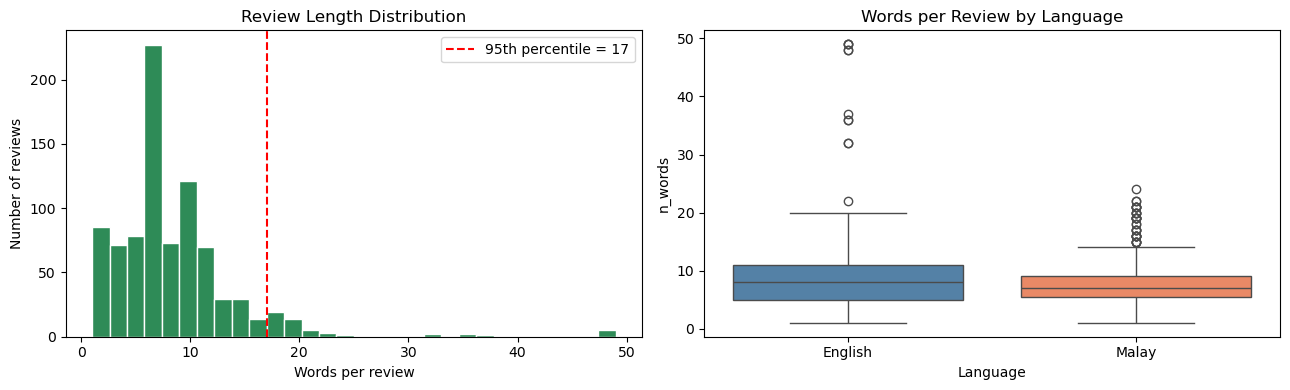

count    849.000000
mean       8.297998
std        5.636974
min        1.000000
25%        5.000000
50%        7.000000
75%       10.000000
max       49.000000
Name: n_words, dtype: float64


In [24]:
df['n_words'] = df['Review'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Word count histogram
axes[0].hist(df['n_words'], bins=30, color='seagreen', edgecolor='white')
axes[0].set_xlabel('Words per review')
axes[0].set_ylabel('Number of reviews')
axes[0].set_title('Review Length Distribution')
axes[0].axvline(df['n_words'].quantile(0.95), color='red', linestyle='--',
                label=f'95th percentile = {int(df["n_words"].quantile(0.95))}')
axes[0].legend()

# Word count by language
sns.boxplot(data=df, x='Language', y='n_words', hue='Language', ax=axes[1],
            palette={'English':'steelblue', 'Malay':'coral'}, legend=False)
axes[1].set_title('Words per Review by Language')

plt.tight_layout()
plt.show()

print(df['n_words'].describe())

## Sentiment Class Balance

The scores are classified into 3 sentiment classes instead of using regression. The dataset has label noise where the same review appears with different scores, for example "Meh." appears with scores 4, 4.8, 5, 5, 5 across different rows. A regression model would struggle to predict a single consistent number from these. Grouping into classes avoids this since all five scores fall into neutral regardless of the exact value.

#### Why 3 classes (not 2 or 5)
Three classes are chosen because the score distribution histogram shows 3 clusters: a concentration of negative reviews near 0-2, a smaller middle group around 4-6, and a dominant spike of positive reviews near 10. The thresholds are set between these clusters:
- Negative: score < 4 (cluster near 0-2)
- Neutral: 4-7 (middle cluster around 4-6)
- Positive: >= 7 (spike near 10)

**Two classes**: The histogram shows a clear middle cluster around 4-6 that does not belong with either the negatives near 0-2 or the spike near 10. Forcing a "Meh." review into positive or negative would misclassify reviews that are genuinely neutral.

**Five classes**: The dataset has only 849 rows after cleaning. After the 80/10/10 stratified split, the smallest class in a 5-class setup would get around 50 to 60 training rows, too few for an RNN to learn a stable representation.

The three classes are reasonably balanced with a mild skew toward positive reviews, matching the spike at 10 visible in the distribution. Both languages show a similar spread as seen in the boxplot.

In [25]:
# classify scores into 3 sentiment classes
def to_sentiment(s):
    if s < 4:
        return 'negative'
    elif s < 7:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['Score'].apply(to_sentiment)

# Plot order and consistent colour map (reused throughout the notebook)
order = ['negative', 'neutral', 'positive']
palette = {'negative':'firebrick', 'neutral':'goldenrod', 'positive':'seagreen'}

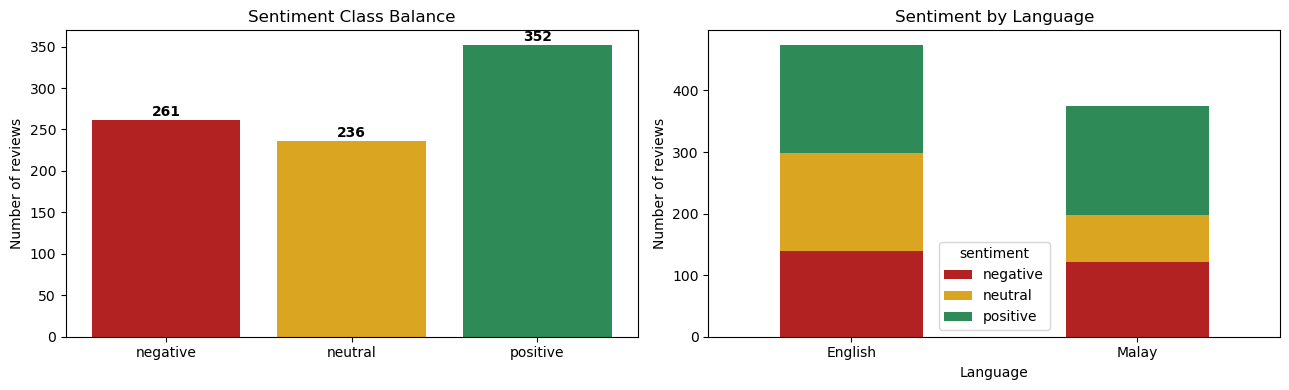

sentiment
negative    261
neutral     236
positive    352
Name: count, dtype: int64


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Overall class balance
counts = df['sentiment'].value_counts().reindex(order)
axes[0].bar(counts.index, counts.values, color=[palette[s] for s in counts.index])
axes[0].set_title('Sentiment Class Balance')
axes[0].set_ylabel('Number of reviews')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Class balance per language
ct = pd.crosstab(df['Language'], df['sentiment']).reindex(columns=order)
ct.plot(kind='bar', stacked=True, ax=axes[1], color=[palette[s] for s in order])
axes[1].set_title('Sentiment by Language')
axes[1].set_ylabel('Number of reviews')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(counts)

In [27]:
# Quick check that the collapsed dataframe has a similar class balance
df_collapsed['sentiment'] = df_collapsed['Score'].apply(to_sentiment)
print(df_collapsed['sentiment'].value_counts())

sentiment
positive    340
negative    232
neutral     221
Name: count, dtype: int64


### Top Words by Sentiment
The most frequent content words in each sentiment class should look semantically appropriate to that class.

In [28]:
# Simple word tokenizer used ONLY for the top-words EDA plot below.
# Modelling uses Keras Tokenizer instead.
def simple_tokens(text):
    text = str(text).lower().replace('’', "'").replace('‘', "'")
    text = re.sub(r"[^\w\s']", ' ', text)
    return [t for t in text.split() if len(t) > 1]

In [29]:
# Stopwords: function words AND food/topic words that appear in every class.
# Filtered out so the top-words plot surfaces sentiment-bearing vocabulary.
# Used ONLY for this EDA plot, NOT during modelling.
STOPWORDS = {
    # English function words
    'the','a','an','and','or','but','is','was','are','were','be','to','of','in','on','at',
    'for','with','by','from','as','it','its','this','that','these','those',
    'i','you','he','she','we','they','my','your','our','their','me','him','her','us','them',
    'so','not','no','do','did','does','have','has','had','can','could','will','would','just',
    'too','very','really','also','than','then','if','when','what','which','who','how',
    # Malay function words
    'yang','dan','di','ke','dari','untuk','dengan','pada','ini','itu','tidak','akan',
    'saya','kami','kita','dia','mereka','ada','adalah','lagi','juga','pun','sudah',
    'belum','boleh','tapi','tetapi','atau','kalau','jika','seperti','macam','ni','tu','la',
    # Food / topic words (appear in every class, don't distinguish sentiment)
    'pizza','pizzanya','sambal','satay','mayo','sauce','crust','topping','toppings',
    'flavor','flavors','taste','tasted','fusion','bite','roti','rasa',
}

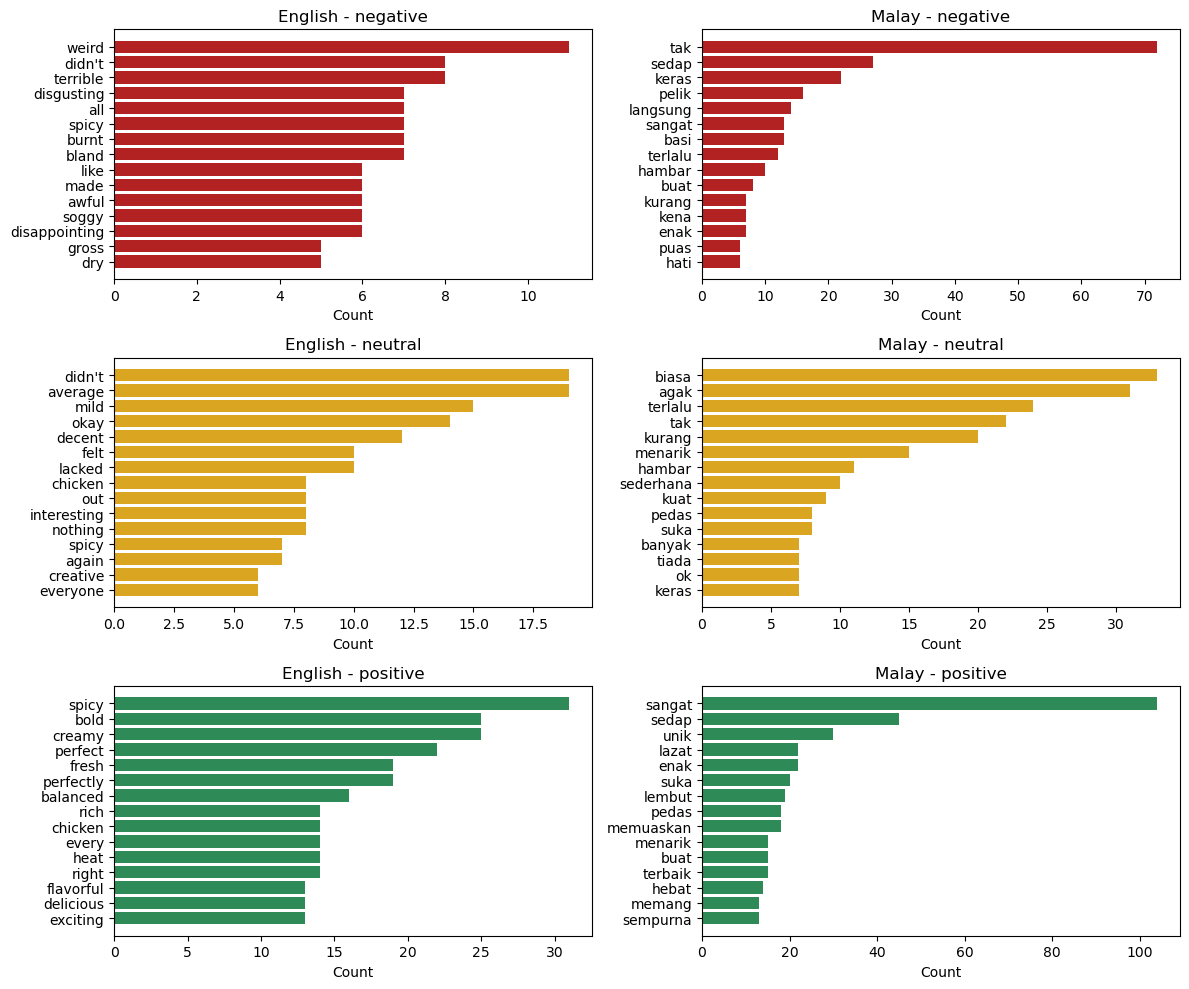

In [30]:
# Plot top 15 sentiment-bearing words per (sentiment, language) cell
top_n = 15
languages = ['English', 'Malay']
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

for row, sent in enumerate(order):
    for col, lang in enumerate(languages):
        ax = axes[row, col]
        subset = df[(df['sentiment'] == sent) & (df['Language'] == lang)]
        tokens = []
        for review in subset['Review']:
            tokens.extend(simple_tokens(review))
        tokens = [t for t in tokens if t not in STOPWORDS]
        top = Counter(tokens).most_common(top_n)
        if top:
            words, freqs = zip(*top)
            ax.barh(range(len(words)), freqs, color=palette[sent])
            ax.set_yticks(range(len(words)))
            ax.set_yticklabels(words)
            ax.invert_yaxis()
        ax.set_title(f'{lang} - {sent}')
        ax.set_xlabel('Count')

plt.tight_layout()
plt.show()

### Findings
Both languages now show clear sentiment vocabulary.

- English negatives are led by "weird","didn't", "terrible", "disgusting", "burnt", "bland", "awful" and "soggy".
- English positives feature "bold", "creamy", "perfect", "fresh", "balanced", "flavorful", "delicious" and "exciting".
- Malay negatives are dominated by "tak" (not), "keras" (hard), "pelik" (weird), "basi" (stale) and "hambar" (bland).
- Malay positives use "sangat" (very), "sedap" (delicious), "lazat" (tasty), "unik" (unique), "lembut" (soft) and "sempurna" (perfect).
- "didn't" being the second most common word in English negative reviews shows that negation words carry strong sentiment signal and shouldn't be stripped during preprocessing. "tak" plays the same role for Malay.
- Some words like "spicy" and "sedap" appear across multiple classes since they're context dependent (e.g. "sedap" appears in negatives as part of "tak sedap" meaning "not delicious").

### Sentence Count
Count sentences per review to plan sentence-splitting augmentation, which was the hint in the original CSV (column 3).

In [31]:
# Sentence splitter for EDA. Used again in the augmentation step later.
def count_sentences(text):
    parts = re.split(r'(?<=[.!?])\s+', str(text).strip())
    return len([p for p in parts if len(p) > 1])

df['n_sentences'] = df['Review'].apply(count_sentences)

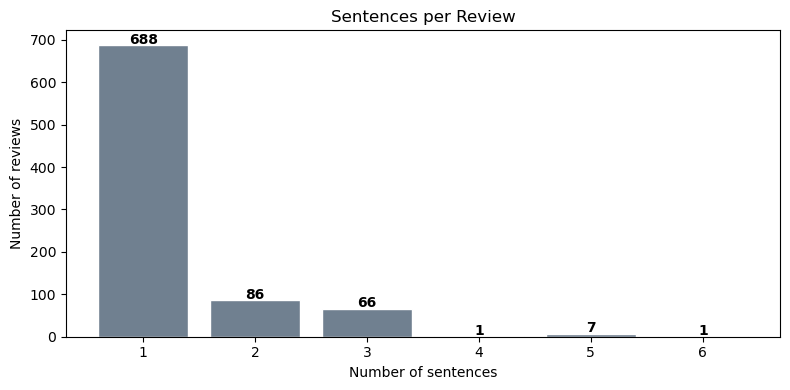

Reviews with 2 or more sentences: 161 / 849
Extra rows from sentence splitting: ~254


In [32]:
fig, ax = plt.subplots(figsize=(8, 4))
counts = df['n_sentences'].value_counts().sort_index()
ax.bar(counts.index, counts.values, color='slategrey', edgecolor='white')
ax.set_xlabel('Number of sentences')
ax.set_ylabel('Number of reviews')
ax.set_title('Sentences per Review')
for i, v in zip(counts.index, counts.values):
    ax.text(i, v + 3, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

multi_sent = (df['n_sentences'] >= 2).sum()
total_sent = df['n_sentences'].sum()
print(f'Reviews with 2 or more sentences: {multi_sent} / {len(df)}')
print(f'Extra rows from sentence splitting: ~{total_sent - len(df)}')

About 19% of reviews have 2 or more sentences. Splitting them into individual sentences will give around 250 extra rows for training.

## Reasons to not use nltk stopword removal
- Removes negation words that are important for this dataset like "didn't", leading to the model to classify a negative review as positive.
- Does not support Malay, so applying it to a bilingual dataset would strip common English function words while leaving Malay equivalents untouched.
- If I were to use NLTK for English but a manual list for Malay, it creates an "unfair" or inconsistent preprocessing pipeline. This imbalance in how the two languages are cleaned could lead the model to favor or struggle with one language over the other.
- With the median word count per review at 7, the reviews are already very short. Removing even 2–3 stopwords significantly reduces the available data for the model to learn from, increasing the risk of losing the core message.

## Reasons to not use lemmatization
- NLTK's WordNet lemmatizer is English-only. English words get lemmatized to base forms but Malay words like "lazatnya", "sedapnya", "kerasnya" are left untouched. Similarly to stopword removal, using a library for English and manual for Malay would break the consistency the tokenizer relies on.
- The median word count per review is 7 words, meaning most words are already in their dictionary form, lemmatization will have little upside

# Data Preprocessing
The cleaned data needs four things before it can go into a model: text normalisation, label encoding, a train/val/test split, and tokenization. Augmentation happens after the split, on the training set only.

In [33]:
# Drop helper columns added during EDA
df = df.drop(columns=['n_words', 'sentiment', 'n_sentences'])
df_collapsed = df_collapsed.drop(columns=['sentiment'])
display(df.head())
display(df_collapsed.head())

,Review,Score,Language
0,Disgusting.,1.0,English
1,Loved the sambal kick!,10.0,English
2,Loved the sambal kick!,0.1,English
3,Loved the sambal kick!,5.0,English
4,"Satay on pizza? Surprisingly worked. Tasty, un...",7.0,English


,Review,Language,Score
0,A beautifully bold and flavorful fusion pizza ...,English,9.86
1,"A bold, beautiful marriage of flavors that exc...",English,9.80
2,A creative and well-executed pizza. The sambal...,English,9.40
3,A decent pizza that didn’t impress much.,English,5.20
4,A delicious fusion pizza that hits all the rig...,English,9.90


## Text Normalisation
Curly quotes (Unicode smart quotes) from phones and word processors make identical words look like different tokens to the tokenizer. Straighten them out on both dataframes before anything else.

In [34]:
# Replace curly quotes with straight equivalents on both dataframes
for frame in [df, df_collapsed]:
    frame['Review'] = (frame['Review']
        .str.replace('‘', "'", regex=False)
        .str.replace('’', "'", regex=False)
        .str.replace('“', '"', regex=False)
        .str.replace('”', '"', regex=False)
    )

## Label Encoding
Convert the continuous score into a 3-class integer label using the same thresholds from the EDA: negative (score < 4) → 0, neutral (4–7) → 1, positive (>= 7) → 2.

In [35]:
def to_label(s):
    if s < 4:
        return 0
    elif s < 7:
        return 1
    else:
        return 2

df['label'] = df['Score'].apply(to_label)
df_collapsed['label'] = df_collapsed['Score'].apply(to_label)

print('df label counts:')
print(df['label'].value_counts().sort_index())
print('-' * 25)
print('df_collapsed label counts:')
print(df_collapsed['label'].value_counts().sort_index())

df label counts:
label
0    261
1    236
2    352
Name: count, dtype: int64
-------------------------
df_collapsed label counts:
label
0    232
1    221
2    340
Name: count, dtype: int64


## Train / Val / Test Split
Split 80/10/10, stratified by label so class proportions are preserved across all three sets. The split is done before augmentation to prevent any augmented rows from leaking into val or test.

The split is done at the unique-review level. Without this, the same review text appearing multiple times with different labels (label noise) could land in both train and test, inflating metrics.

Both dataset versions are split independently so they can be trained and compared as a clean A/B test.

In [36]:
from sklearn.model_selection import train_test_split

def split_dataset(frame):
    """Split a dataframe 80/10/10 grouped by unique Review text to prevent leakage."""
    # One row per unique review, labelled by its most common label (for stratification)
    unique = (frame.groupby('Review')['label']
                   .agg(lambda x: x.value_counts().index[0])
                   .reset_index())

    # 80% train, 20% temp → split temp 50/50 into val and test
    rev_train, rev_temp, _, y_temp = train_test_split(
        unique['Review'].values, unique['label'].values,
        test_size=0.2, random_state=SEED, stratify=unique['label'].values
    )
    rev_val, rev_test = train_test_split(
        rev_temp, test_size=0.5, random_state=SEED, stratify=y_temp
    )

    # Fan unique reviews back out to all rows belonging to them
    def rows_for(reviews):
        mask = frame['Review'].isin(reviews)
        return frame.loc[mask, 'Review'].values, frame.loc[mask, 'label'].values

    X_train, y_train = rows_for(rev_train)
    X_val, y_val = rows_for(rev_val)
    X_test, y_test = rows_for(rev_test)
    return X_train, X_val, X_test, y_train, y_val, y_test

In [37]:
# Apply the split to both dataset versions
X_train,   X_val,   X_test,   y_train,   y_val,   y_test   = split_dataset(df)
X_train_c, X_val_c, X_test_c, y_train_c, y_val_c, y_test_c = split_dataset(df_collapsed)

print(f'df train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test)}')
print(f'df_collapsed train: {len(X_train_c)}, val: {len(X_val_c)}, test: {len(X_test_c)}')

df train: 683, val: 84, test: 82
df_collapsed train: 634, val: 79, test: 80


## Sentence Splitting Augmentation
About 19% of training reviews have two or more sentences. Splitting them into individual sentences and assigning each the parent label gives extra training rows without collecting new data.

The split is applied only to the training set. Val and test stay as-is so evaluation reflects real review-length inputs.

In [38]:
def split_sentences(reviews, labels):
    """For each multi-sentence review, emit each sentence as its own row with the parent label."""
    new_reviews, new_labels = [], []
    for review, label in zip(reviews, labels):
        sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', str(review)) if len(s.strip()) > 1]
        if len(sentences) > 1:
            new_reviews.extend(sentences)
            new_labels.extend([label] * len(sentences))
        else:
            new_reviews.append(review)
            new_labels.append(label)
    return np.array(new_reviews), np.array(new_labels)

In [39]:
# Augment training sets only (val and test untouched)
X_train_aug, y_train_aug = split_sentences(X_train, y_train)
X_train_aug_c, y_train_aug_c = split_sentences(X_train_c, y_train_c)

print(f'df before aug: {len(X_train)}, after: {len(X_train_aug)}')
print(f'df_collapsed before aug: {len(X_train_c)}, after: {len(X_train_aug_c)}')

df before aug: 683, after: 893
df_collapsed before aug: 634, after: 830


## Tokenization
Fit a Keras Tokenizer on the augmented training set only. Fitting on val or test would let the vocabulary reflect words the model isn't supposed to have seen yet. The tokenizer is then used to transform all splits.

Vocabulary is capped at 3,000 tokens. The 95th percentile review length from the EDA was 17 words, so sequences are padded or truncated to 20.

In [40]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB = 3000
MAX_LEN = 20

def build_tokenizer_and_pad(X_train_aug, X_train, X_val, X_test):
    """Fit a tokenizer on the augmented training data, return padded sequences for all splits."""
    tok = Tokenizer(num_words=MAX_VOCAB, lower=True, oov_token='<OOV>')
    tok.fit_on_texts(X_train_aug)

    def encode(X):
        return pad_sequences(
            tok.texts_to_sequences(X),
            maxlen=MAX_LEN, padding='pre', truncating='post'
        )

    return tok, encode(X_train_aug), encode(X_train), encode(X_val), encode(X_test)

In [41]:
# Build separate tokenizers for the two dataset versions
tok, X_train_aug_pad, X_train_pad, X_val_pad, X_test_pad = build_tokenizer_and_pad(
    X_train_aug, X_train, X_val, X_test
)
tok_c, X_train_aug_pad_c, X_train_pad_c, X_val_pad_c, X_test_pad_c = build_tokenizer_and_pad(
    X_train_aug_c, X_train_c, X_val_c, X_test_c
)

vocab_size = min(MAX_VOCAB, len(tok.word_index) + 1)
vocab_size_c = min(MAX_VOCAB, len(tok_c.word_index) + 1)

print(f'df vocab size: {vocab_size}, train shape: {X_train_aug_pad.shape}')
print(f'df_collapsed vocab size: {vocab_size_c}, train shape: {X_train_aug_pad_c.shape}')

df vocab size: 794, train shape: (893, 20)
df_collapsed vocab size: 783, train shape: (830, 20)


Each sequence is now a fixed-length array of integers. Index 0 is padding, index 1 is the OOV token. These arrays go directly into the Embedding layer.

# Modelling
Three architectures are compared: SimpleRNN as the baseline, BiLSTM as the first improvement, and BiGRU as the second. All three are trained on the same word-level tokenized, augmented label-noise dataset to keep the comparison fair.

## Evaluation Setup
Macro-F1 is the primary metric since the classes are imbalanced. Accuracy alone would flatter a model that ignores the minority class. The confusion matrix shows where errors cluster.

In [42]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

CLASS_NAMES = ['negative', 'neutral', 'positive']

def get_f1(model, X, y):
    """Macro-F1 only. Used during model-to-model comparisons."""
    y_pred = model.predict(X, verbose=0).argmax(axis=1)
    return f1_score(y, y_pred, average='macro')

def evaluate(model, X, y, title=''):
    """Full evaluation: classification report + confusion matrix. Used on the final best model."""
    y_pred = model.predict(X, verbose=0).argmax(axis=1)
    print(f'--- {title} ---')
    print(classification_report(y, y_pred, target_names=CLASS_NAMES))
    cm = confusion_matrix(y, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap='Blues')
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return f1_score(y, y_pred, average='macro')

In [43]:
def plot_history(history, title=''):
    """Plot training vs validation loss and accuracy across epochs."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['loss'], label='train')
    axes[0].plot(history.history['val_loss'], label='val')
    axes[0].set_title(f'{title} Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[1].plot(history.history['accuracy'], label='train')
    axes[1].plot(history.history['val_accuracy'], label='val')
    axes[1].set_title(f'{title} Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

## Baseline: SimpleRNN
The simplest possible RNN: one embedding layer trained from scratch, one SimpleRNN layer, a softmax output. This sets the floor every subsequent model needs to beat. EarlyStopping monitors val_loss and restores the best weights so the reported scores reflect the best generalisation point, not the final epoch.

In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

EMBED_DIM = 64

# Baseline architecture
baseline = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM),
    SimpleRNN(64),
    Dense(3, activation='softmax')
], name='baseline_rnn')

baseline.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
baseline.summary()

Model: "baseline_rnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [45]:
# Train baseline
history_baseline = baseline.fit(
    X_train_aug_pad, y_train_aug,
    validation_data=(X_val_pad, y_val),
    epochs=30, batch_size=32, verbose=1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

Epoch 1/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.4434 - loss: 1.0550 - val_accuracy: 0.6190 - val_loss: 0.9704
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6585 - loss: 0.8692 - val_accuracy: 0.7143 - val_loss: 0.8038
Epoch 3/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8309 - loss: 0.6027 - val_accuracy: 0.7143 - val_loss: 0.5967
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8925 - loss: 0.3896 - val_accuracy: 0.7143 - val_loss: 0.6309
Epoch 5/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9183 - loss: 0.2959 - val_accuracy: 0.7619 - val_loss: 0.5706
Epoch 6/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9317 - loss: 0.2060 - val_accuracy: 0.7738 - val_loss: 0.5666
Epoch 7/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9440 - loss: 0.1640 - val_accuracy: 0.7738 - val_loss: 0.6071
Epoch 8/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9429 - loss: 0.1398 - val_accuracy: 0.7857 - val_los

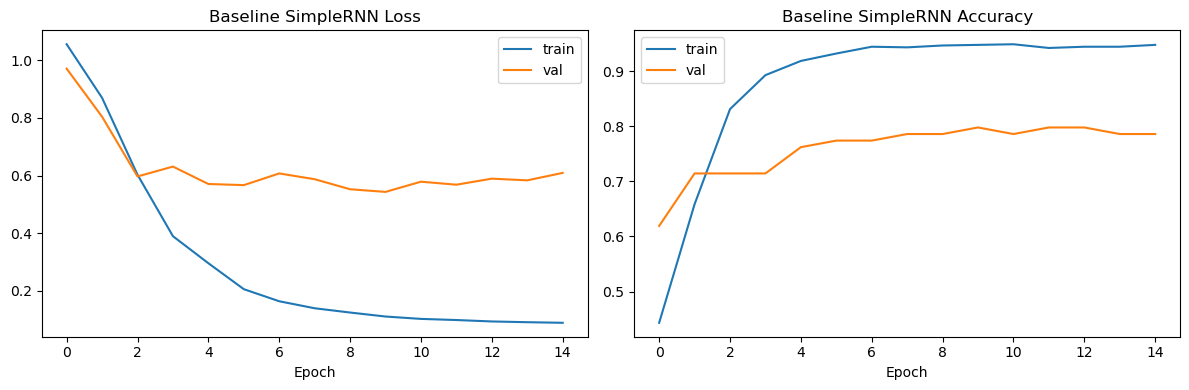

In [46]:
plot_history(history_baseline, 'Baseline SimpleRNN')

In [47]:
f1_baseline_val  = get_f1(baseline, X_val_pad,  y_val)
f1_baseline_test = get_f1(baseline, X_test_pad, y_test)
print(f'Baseline SimpleRNN  val: {f1_baseline_val:.3f} test: {f1_baseline_test:.3f}')

Baseline SimpleRNN  val: 0.787 test: 0.843


### Curve evaluation
- ran 15 epochs
- Overfitting: After Epoch 2, the training loss continued to plunge while the validation loss flattened out and began to fluctuate upward.
- A similar gap happens in the accuracy plot at Epoch 2. The training accuracy climbs toward 95%, while the validation accuracy plateaus and stalls around 78–80%.

## BiLSTM
The baseline has two problems visible in the loss curves: it overfits quickly and SimpleRNN only reads left to right, so a sentiment word at the end of a review cannot influence earlier tokens.

**Bidirectional LSTM** runs two LSTMs in parallel, forward and backward, so both directions of context are available at every position. LSTM gating avoids the vanishing gradient problem that limits plain RNNs. **Recurrent dropout** targets the hidden state transitions inside the LSTM gates. **Output dropout** adds a second regularisation point after the LSTM. **Class weighting** rebalances the gradient since positive reviews outnumber neutral and negative ones.

In [48]:
from tensorflow.keras.layers import LSTM, Bidirectional, Dropout
from sklearn.utils.class_weight import compute_class_weight

# Class weights rebalance the gradient for the imbalanced classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_aug),
    y=y_train_aug
)
class_weight_dict = dict(enumerate(class_weights))
print('Class weights:', class_weight_dict)

Class weights: {0: np.float64(1.2559774964838255), 1: np.float64(1.1537467700258397), 2: np.float64(0.7479061976549414)}


In [49]:
# BiLSTM architecture
improved = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM),
    Bidirectional(LSTM(64, recurrent_dropout=0.2)),
    Dropout(0.4),
    Dense(3, activation='softmax')
], name='bilstm')

improved.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
improved.summary()

Model: "bilstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [50]:
# Train BiLSTM
history_improved = improved.fit(
    X_train_aug_pad, y_train_aug,
    validation_data=(X_val_pad, y_val),
    epochs=30, batch_size=32,
    class_weight=class_weight_dict, verbose=1,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ModelCheckpoint('best_LSTM_model_partB.h5', monitor='val_loss', save_best_only=True),
    ]
)

Epoch 1/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.3057 - loss: 1.0961 - val_accuracy: 0.4286 - val_loss: 1.0766
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.6103 - loss: 1.0343 - val_accuracy: 0.7381 - val_loss: 0.8784
Epoch 3/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6842 - loss: 0.8310 - val_accuracy: 0.8095 - val_loss: 0.5036
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8320 - loss: 0.5003 - val_accuracy: 0.8452 - val_loss: 0.4373
Epoch 5/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8992 - loss: 0.3098 - val_accuracy: 0.8690 - val_loss: 0.3961
Epoch 6/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9205 - loss: 0.2336 - val_accuracy: 0.8690 - val_loss: 0.4354
Epoch 7/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9216 - loss: 0.2065 - val_accuracy: 0.8810 - val_loss: 0.3741
Epoch 8/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9362 - loss: 0.1735 - val_accuracy: 0.8810 - v

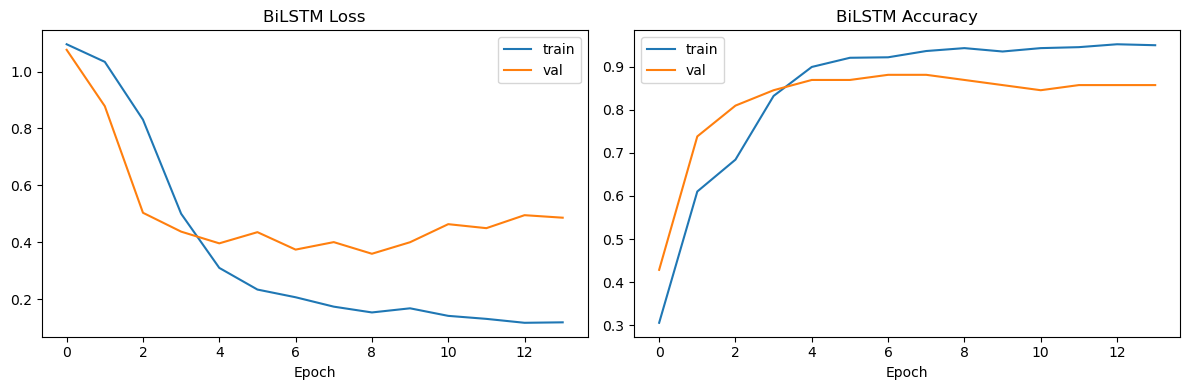

In [51]:
plot_history(history_improved, 'BiLSTM')

In [52]:
f1_improved_val  = get_f1(improved, X_val_pad,  y_val)
f1_improved_test = get_f1(improved, X_test_pad, y_test)
print(f'BiLSTM val: {f1_improved_val:.3f} test: {f1_improved_test:.3f}')

BiLSTM val: 0.865 test: 0.894


### Curve evaluation
- ran 14 epochs
- Overfitting: Started at around epoch 4, with a more clear separation between training and val loss at epoch 8
- Accuracy: val accuracy initially outperformed the training accuracy, but the curves crossed around Epoch 4. Training accuracy continued climbing toward 95%, while validation accuracy peaked at 88% Epoch 7 before slowly degrading.

## BiGRU
GRU uses two gates instead of LSTM's three and merges the cell state and hidden state into one, giving fewer parameters. On a small dataset like this, fewer parameters can mean less overfitting. Same architecture as the BiLSTM to keep the comparison fair.

In [53]:
from tensorflow.keras.layers import GRU

# BiGRU architecture (mirrors BiLSTM for a fair comparison)
gru_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM),
    Bidirectional(GRU(64, recurrent_dropout=0.2)),
    Dropout(0.4),
    Dense(3, activation='softmax')
], name='bigru')

gru_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
gru_model.summary()

Model: "bigru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [54]:
# Train BiGRU
history_gru = gru_model.fit(
    X_train_aug_pad, y_train_aug,
    validation_data=(X_val_pad, y_val),
    epochs=30, batch_size=32,
    class_weight=class_weight_dict, verbose=1,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ModelCheckpoint('best_gru_partB.h5', monitor='val_loss', save_best_only=True),
    ]
)

Epoch 1/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.3270 - loss: 1.0955 - val_accuracy: 0.5833 - val_loss: 1.0778
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7312 - loss: 1.0308 - val_accuracy: 0.7381 - val_loss: 0.9256
Epoch 3/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7783 - loss: 0.7242 - val_accuracy: 0.7976 - val_loss: 0.5067
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8611 - loss: 0.4468 - val_accuracy: 0.8095 - val_loss: 0.4002
Epoch 5/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8600 - loss: 0.3637 - val_accuracy: 0.8214 - val_loss: 0.3938
Epoch 6/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9093 - loss: 0.2592 - val_accuracy: 0.8452 - val_loss: 0.3653
Epoch 7/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9418 - loss: 0.1991 - val_accuracy: 0.8810 - val_loss: 0.3406
Epoch 8/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9451 - loss: 0.1647 - val_accuracy: 0.8929 - v

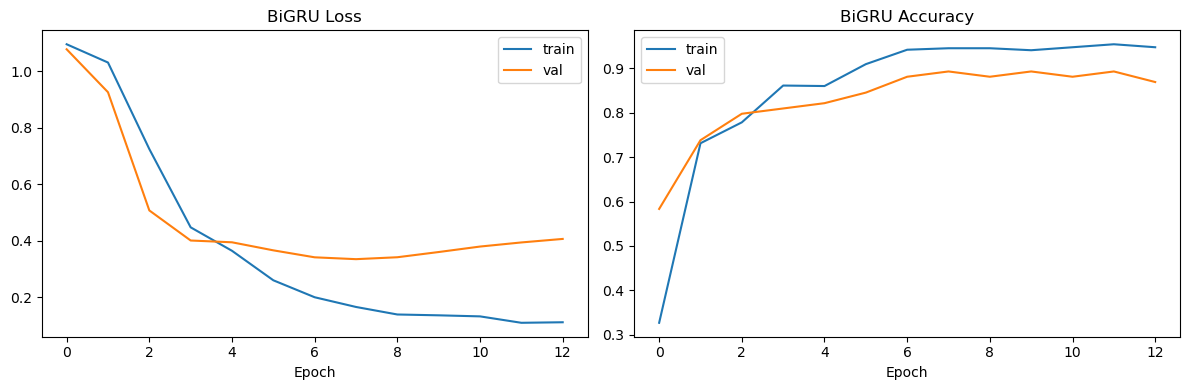

In [55]:
plot_history(history_gru, 'BiGRU')

In [56]:
f1_gru_val  = get_f1(gru_model, X_val_pad,  y_val)
f1_gru_test = get_f1(gru_model, X_test_pad, y_test)

print(f'{"Model":<20} {"Val F1":>8} {"Test F1":>9}')
print('-' * 40)
print(f'{"SimpleRNN":<20} {f1_baseline_val:>8.3f} {f1_baseline_test:>9.3f}')
print(f'{"BiLSTM":<20} {f1_improved_val:>8.3f} {f1_improved_test:>9.3f}')
print(f'{"BiGRU":<20} {f1_gru_val:>8.3f} {f1_gru_test:>9.3f}')

Model                  Val F1   Test F1
----------------------------------------
SimpleRNN               0.787     0.843
BiLSTM                  0.865     0.894
BiGRU                   0.883     0.895


### Curve evaluation
- ran 13 epochs
- Overfitting: Up to Epoch 4, training and validation loss decrease together. After Epoch 4, training loss continuously drops toward 0.1, whereas the validation loss flattens out, being the lowest at Epoch 7 (around 0.34), and then gradually increasing.
- The training and validation accuracy were similar until Epoch 3. After Epoch 3, training accuracy sharply increases to 95%, while validation accuracy grows at a slower rate, peaking at Epoch 7 (around 89%) before slightly dropping.

# Model Improvement
Three experiments to push the model further:
1. K-fold cross-validation to confirm the architecture winner is not noise from a single split.
2. A/B test on the dataset itself: label noise kept vs collapsed to medians.
3. Pretrained fastText embeddings to give the model multilingual word knowledge it can't learn from 700 training rows.

## Architecture Confirmation: 5-Fold Cross-Validation
On a val set of 84 rows, one prediction shifts macro-F1 by about 1.2%, so a single-split comparison between BiLSTM and BiGRU could be noise. 5-fold cross-validation runs each model five times on different train/val splits and reports mean and standard deviation of macro-F1 across folds.

GroupKFold is used so that the same review text never appears in both the training and validation fold, consistent with the leakage fix applied during the main split.

In [57]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder

# Combine non-augmented train and val for k-fold (test is held out)
X_kf_raw = np.concatenate([X_train, X_val])
X_kf = np.concatenate([X_train_pad, X_val_pad])
y_kf = np.concatenate([y_train, y_val])

# Group by unique review text so the same review never appears in both fold sides
groups = LabelEncoder().fit_transform(X_kf_raw)

N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)

In [58]:
# Builder functions so each fold gets a fresh, identical model
def build_bilstm():
    m = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBED_DIM),
        Bidirectional(LSTM(64, recurrent_dropout=0.2)),
        Dropout(0.4),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

def build_bigru():
    m = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBED_DIM),
        Bidirectional(GRU(64, recurrent_dropout=0.2)),
        Dropout(0.4),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

In [59]:
def run_kfold(build_fn, label):
    """Train build_fn() once per fold, return array of macro-F1 scores."""
    scores = []
    for fold, (tr_idx, vl_idx) in enumerate(gkf.split(X_kf, y_kf, groups), 1):
        tf.random.set_seed(SEED + fold)
        X_tr, X_vl = X_kf[tr_idx], X_kf[vl_idx]
        y_tr, y_vl = y_kf[tr_idx], y_kf[vl_idx]
        cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
        model = build_fn()
        model.fit(
            X_tr, y_tr,
            validation_data=(X_vl, y_vl),
            epochs=30, batch_size=32, verbose=0,
            class_weight=dict(enumerate(cw)),
            callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
        )
        s = f1_score(y_vl, model.predict(X_vl, verbose=0).argmax(axis=1), average='macro')
        scores.append(s)
        print(f'  {label} fold {fold}: {s:.3f}')
    return np.array(scores)

In [60]:
# Run BiLSTM across all 5 folds
print('BiLSTM:')
bilstm_kf = run_kfold(build_bilstm, 'BiLSTM')
print(f'Mean: {bilstm_kf.mean():.3f} ± {bilstm_kf.std():.3f}')

BiLSTM:
  BiLSTM fold 1: 0.870
  BiLSTM fold 2: 0.913
  BiLSTM fold 3: 0.841
  BiLSTM fold 4: 0.897
  BiLSTM fold 5: 0.775
Mean: 0.859 ± 0.049


In [61]:
# Run BiGRU across all 5 folds
print('BiGRU:')
bigru_kf = run_kfold(build_bigru, 'BiGRU')
print(f'Mean: {bigru_kf.mean():.3f} ± {bigru_kf.std():.3f}')

BiGRU:
  BiGRU fold 1: 0.854
  BiGRU fold 2: 0.851
  BiGRU fold 3: 0.872
  BiGRU fold 4: 0.829
  BiGRU fold 5: 0.814
Mean: 0.844 ± 0.020


In [62]:
print(f'{"Model":<10} {"Mean F1":>8} {"Std":>6}')
print('-' * 27)
print(f'{"BiLSTM":<10} {bilstm_kf.mean():>8.3f} {bilstm_kf.std():>6.3f}')
print(f'{"BiGRU":<10} {bigru_kf.mean():>8.3f} {bigru_kf.std():>6.3f}')

Model       Mean F1    Std
---------------------------
BiLSTM        0.859  0.049
BiGRU         0.844  0.020


BiLSTM came out with a slightly higher mean (0.859 vs 0.844) but a standard deviation more than twice as large (0.049 vs 0.020), swinging from 0.775 to 0.913 across folds. BiGRU stayed between 0.814 and 0.872 on every fold. A model whose performance varies by 0.138 across different data splits is less reliable than one that holds steady, regardless of which has the higher average. Combined with BiGRU winning the single-split val comparison (0.883 vs 0.865), BiGRU is the better choice.

## Dataset Version: Label Noise vs Collapsed
GRU is confirmed as the better architecture. The same comparison is now run across dataset versions: `df` keeps all label-noisy rows, `df_collapsed` collapses reviews with inconsistent scores to a single row using the median. Both BiLSTM and BiGRU are tested on collapsed to show whether the dataset effect depends on architecture.

In [63]:
# Class weights for the collapsed dataset
class_weights_c = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_aug_c),
    y=y_train_aug_c
)
class_weight_dict_c = dict(enumerate(class_weights_c))

In [64]:
# BiLSTM trained on the collapsed dataset
improved_c = Sequential([
    Embedding(input_dim=vocab_size_c, output_dim=EMBED_DIM),
    Bidirectional(LSTM(64, recurrent_dropout=0.2)),
    Dropout(0.4),
    Dense(3, activation='softmax')
], name='bilstm_collapsed')

improved_c.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

improved_c.fit(
    X_train_aug_pad_c, y_train_aug_c,
    validation_data=(X_val_pad_c, y_val_c),
    epochs=30, batch_size=32,
    class_weight=class_weight_dict_c, verbose=1,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ModelCheckpoint('best_collapsed_bilstm_partB.h5', monitor='val_loss', save_best_only=True),
    ]
)

f1_c_val  = get_f1(improved_c, X_val_pad_c,  y_val_c)
f1_c_test = get_f1(improved_c, X_test_pad_c, y_test_c)
print(f'BiLSTM collapsed val:{f1_c_val:.3f} test:{f1_c_test:.3f}')

Epoch 1/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - accuracy: 0.3277 - loss: 1.0950 - val_accuracy: 0.7089 - val_loss: 1.0784
Epoch 2/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.5699 - loss: 1.0499 - val_accuracy: 0.8481 - val_loss: 0.9469
Epoch 3/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6928 - loss: 0.8603 - val_accuracy: 0.8481 - val_loss: 0.5400
Epoch 4/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8169 - loss: 0.5520 - val_accuracy: 0.8228 - val_loss: 0.4165
Epoch 5/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9024 - loss: 0.3311 - val_accuracy: 0.8481 - val_loss: 0.3990
Epoch 6/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9361 - loss: 0.2047 - val_accuracy: 0.8354 - val_loss: 0.4189
Epoch 7/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9470 - loss: 0.1604 - val_accuracy: 0.8608 - val_loss: 0.4047
Epoch 8/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9578 - loss: 0.1192 - val_accuracy: 0.8354 - v

In [65]:
# BiGRU trained on the collapsed dataset
gru_collapsed = Sequential([
    Embedding(input_dim=vocab_size_c, output_dim=EMBED_DIM),
    Bidirectional(GRU(64, recurrent_dropout=0.2)),
    Dropout(0.4),
    Dense(3, activation='softmax')
], name='bigru_collapsed')

gru_collapsed.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

gru_collapsed.fit(
    X_train_aug_pad_c, y_train_aug_c,
    validation_data=(X_val_pad_c, y_val_c),
    epochs=30, batch_size=32,
    class_weight=class_weight_dict_c, verbose=1,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ModelCheckpoint('best_gru_collapsed_partB.h5', monitor='val_loss', save_best_only=True),
    ]
)

f1_gru_c_val  = get_f1(gru_collapsed, X_val_pad_c,  y_val_c)
f1_gru_c_test = get_f1(gru_collapsed, X_test_pad_c, y_test_c)
print(f'BiGRU collapsed val: {f1_gru_c_val:.3f} test:{f1_gru_c_test:.3f}')

Epoch 1/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.4265 - loss: 1.0939 - val_accuracy: 0.6709 - val_loss: 1.0700
Epoch 2/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7060 - loss: 1.0258 - val_accuracy: 0.8228 - val_loss: 0.9101
Epoch 3/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7639 - loss: 0.7469 - val_accuracy: 0.7975 - val_loss: 0.4891
Epoch 4/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8506 - loss: 0.4399 - val_accuracy: 0.8608 - val_loss: 0.4094
Epoch 5/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9217 - loss: 0.2613 - val_accuracy: 0.8734 - val_loss: 0.4400
Epoch 6/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9434 - loss: 0.1714 - val_accuracy: 0.8861 - val_loss: 0.4174
Epoch 7/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9578 - loss: 0.1343 - val_accuracy: 0.8734 - val_loss: 0.4603
Epoch 8/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9687 - loss: 0.1135 - val_accuracy: 0.8354 - v

In [66]:
print(f'{"Architecture":<12} {"Label noise val":>16} {"Collapsed val":>14}')
print('-' * 45)
print(f'{"BiLSTM":<12} {f1_improved_val:>16.3f} {f1_c_val:>14.3f}')
print(f'{"BiGRU":<12} {f1_gru_val:>16.3f} {f1_gru_c_val:>14.3f}')

Architecture  Label noise val  Collapsed val
---------------------------------------------
BiLSTM                  0.865          0.823
BiGRU                   0.883          0.840


### Collapsed VS Label Noise Dataset
- Collapsing hurt both architectures on val. Label noise dataset wins by getting better F1 scores and accuracy
- GRU is good enough to learn through noisy labels and benefits from the slightly larger training set (893 vs 830 augmented rows).

## Pretrained Embeddings (fastText)
The vocabulary is small (around 800 unique words) and the training set is small (around 700 rows before augmentation), so the embedding layer learns weak word representations from scratch. Pretrained fastText vectors trained on Common Crawl encode much richer word meaning.

The Malay vectors (`cc.ms.300.vec`) are loaded on top of the English vectors so the same matrix covers both languages. Two strategies are compared: frozen embeddings (vectors fixed, only the RNN and dense layers train) and fine-tuned (all weights including the embedding layer update during training).

In [67]:
import urllib.request
import gzip
import os

# Common Crawl fastText vectors for English and Malay
EMBED_FILES = {'en': 'cc.en.300.vec.gz', 'ms': 'cc.ms.300.vec.gz'}
URLS = {
    'en': 'https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.vec.gz',
    'ms': 'https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.ms.300.vec.gz',
}

# Download once and cache locally
for lang, url in URLS.items():
    fname = EMBED_FILES[lang]
    if not os.path.exists(fname):
        print(f'Downloading {fname}...')
        urllib.request.urlretrieve(url, fname)
    else:
        print(f'{fname} already on disk')

cc.en.300.vec.gz already on disk
cc.ms.300.vec.gz already on disk


In [68]:
def load_vectors(fname):
    """Load a fastText .vec.gz file into a dict of word -> numpy array."""
    vectors = {}
    with gzip.open(fname, 'rt', encoding='utf-8', errors='ignore') as f:
        next(f)  # skip header line (vocab_size dim)
        for line in f:
            parts = line.rstrip().split(' ')
            word = parts[0]
            vec  = np.array(parts[1:], dtype='float32')
            vectors[word] = vec
    return vectors

# Malay vectors overwrite English where a word appears in both.
print('Loading English vectors...')
ft_vectors = load_vectors(EMBED_FILES['en'])
print('Loading Malay vectors...')
ft_vectors.update(load_vectors(EMBED_FILES['ms']))
print(f'Total vectors loaded: {len(ft_vectors)}')

Loading English vectors...
Loading Malay vectors...
Total vectors loaded: 2823004


In [69]:
# Build an embedding matrix aligned to the existing tokenizer's word index
EMBED_DIM_FT = 300
embedding_matrix = np.zeros((vocab_size, EMBED_DIM_FT))
found, missing = 0, 0

for word, idx in tok.word_index.items():
    if idx >= vocab_size:
        continue
    vec = ft_vectors.get(word)
    if vec is not None:
        embedding_matrix[idx] = vec
        found += 1
    else:
        missing += 1

print(f'Vocab coverage: {found}/{found+missing} words ({found/(found+missing)*100:.1f}%)')

Vocab coverage: 777/793 words (98.0%)


In [70]:
def build_ft_bigru(trainable=False):
    """Same BiGRU architecture but with pretrained fastText embeddings."""
    m = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=EMBED_DIM_FT,
            weights=[embedding_matrix],
            trainable=trainable
        ),
        Bidirectional(GRU(64, recurrent_dropout=0.2)),
        Dropout(0.4),
        Dense(3, activation='softmax')
    ], name=f'bigru_ft_{"finetune" if trainable else "frozen"}')
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

ft_cb = [EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]

In [71]:
# Frozen: embedding weights fixed, only RNN and dense layers train
print('--- Frozen embedding ---')
ft_frozen = build_ft_bigru(trainable=False)
ft_frozen.fit(
    X_train_aug_pad, y_train_aug,
    validation_data=(X_val_pad, y_val),
    epochs=30, batch_size=32, verbose=1,
    class_weight=class_weight_dict, callbacks=ft_cb
)

f1_ft_frozen_val = get_f1(ft_frozen, X_val_pad,  y_val)
f1_ft_frozen_test = get_f1(ft_frozen, X_test_pad, y_test)
print(f'Frozen val: {f1_ft_frozen_val:.3f} test: {f1_ft_frozen_test:.3f}')

--- Frozen embedding ---
Epoch 1/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.4211 - loss: 1.0867 - val_accuracy: 0.5595 - val_loss: 1.0652
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5879 - loss: 1.0248 - val_accuracy: 0.5476 - val_loss: 0.9638
Epoch 3/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6204 - loss: 0.9102 - val_accuracy: 0.6310 - val_loss: 0.7561
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6663 - loss: 0.8145 - val_accuracy: 0.6667 - val_loss: 0.7187
Epoch 5/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6988 - loss: 0.7283 - val_accuracy: 0.7381 - val_loss: 0.6562
Epoch 6/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7290 - loss: 0.6564 - val_accuracy: 0.7500 - val_loss: 0.5816
Epoch 7/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7682 - loss: 0.6151 - val_accuracy: 0.7381 - val_loss: 0.5235
Epoch 8/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7794 - loss: 0.5592 -

In [72]:
# Fine-tuned: all weights including embedding update during training
print('--- Fine-tuned embedding ---')
ft_tuned = build_ft_bigru(trainable=True)
ft_tuned.fit(
    X_train_aug_pad, y_train_aug,
    validation_data=(X_val_pad, y_val),
    epochs=30, batch_size=32, verbose=1,
    class_weight=class_weight_dict, callbacks=ft_cb
)

f1_ft_tuned_val = get_f1(ft_tuned, X_val_pad,  y_val)
f1_ft_tuned_test = get_f1(ft_tuned, X_test_pad, y_test)
print(f'Fine-tuned val: {f1_ft_tuned_val:.3f} test: {f1_ft_tuned_test:.3f}')

--- Fine-tuned embedding ---
Epoch 1/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.4356 - loss: 1.0723 - val_accuracy: 0.5476 - val_loss: 1.0158
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.7492 - loss: 0.8429 - val_accuracy: 0.7619 - val_loss: 0.5670
Epoch 3/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8387 - loss: 0.4698 - val_accuracy: 0.8095 - val_loss: 0.4370
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9015 - loss: 0.2847 - val_accuracy: 0.8333 - val_loss: 0.3868
Epoch 5/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9261 - loss: 0.2035 - val_accuracy: 0.8452 - val_loss: 0.4008
Epoch 6/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9295 - loss: 0.1767 - val_accuracy: 0.8452 - val_loss: 0.4254
Epoch 7/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9406 - loss: 0.1564 - val_accuracy: 0.8333 - val_loss: 0.4567
Epoch 8/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9451 - loss: 0.14

In [73]:
print(f'{"Model":<30} {"Val F1":>8} {"Test F1":>9}')
print('-' * 50)
print(f'{"BiGRU (trained embedding)":<30} {f1_gru_val:>8.3f} {f1_gru_test:>9.3f}')
print(f'{"BiGRU (fastText frozen)":<30} {f1_ft_frozen_val:>8.3f} {f1_ft_frozen_test:>9.3f}')
print(f'{"BiGRU (fastText fine-tuned)":<30} {f1_ft_tuned_val:>8.3f} {f1_ft_tuned_test:>9.3f}')

Model                            Val F1   Test F1
--------------------------------------------------
BiGRU (trained embedding)         0.883     0.895
BiGRU (fastText frozen)           0.754     0.833
BiGRU (fastText fine-tuned)       0.825     0.872


## fastText Findings
Both fastText variants (frozen, fine-tuning) did worse than the trained from scratch BiGRU embedding.


### Why custom embedding could have done better
- The embeddings were trained on general web text (Common Crawl), causing the embedding to be unrelated with specialized pizza reviews. **Source** : https://fasttext.cc/docs/en/crawl-vectors.html
-  Fine-tuning outperforming the frozen configuration suggests the pre-trained vectors were trained on contexts too different from pizza reviews to transfer directly.

## Data Augmentation Experiment: Random Swap

Sentence splitting only helped the 19% of reviews with 2 or more sentences. Random swap, one of the four Easy Data Augmentation (EDA) techniques proposed by Wei & Zou (2019), adds more training data on top of that, and it works the same way on both English and Malay rows.

### Random Swap
Random swap picks two random word positions in the review and swaps them. The number of swaps scales with sentence length so longer reviews get more shuffling. For example "the pizza was bland and dry" could become "the pizza was dry and bland" after one swap. The sentiment is unchanged but the word order is now different, giving the model another training row pointing to the same label.

Why it helps:
- **Improves generalization**: The median review is only 7 words, which makes it easy for the model to memorise exact word sequences. Swapping forces it to learn which words matter, not their exact positions.
- **Language-agnostic**: Works on English and Malay rows, unlike synonym replacement which would need WordNet for English and have no equivalent for Malay.
- **Every sentiment-bearing word is preserved**: Important signals like "didn't" or "tak" cannot be lost.
- **Length is preserved**: The augmented training reviews have the same length distribution as the original, so there's no shift between training and test inputs.
- **More training data**: stacks on top of sentence splitting to bring training rows from 893 to 2431 (about 2.7x). On a small dataset like this one, more examples is the most direct way to reduce overfitting and help the model generalize.


In [74]:
def random_swap(words, n=1):
    words = list(words)
    for _ in range(n):
        if len(words) < 2:
            break
        i, j = random.sample(range(len(words)), 2)
        words[i], words[j] = words[j], words[i]
    return words

def swap_augment_one(text, n_aug=2):
    """Generate n_aug swap-augmented copies of a single review."""
    words = text.split()
    if len(words) < 3:  # too short to meaningfully swap
        return []
    out = []
    for _ in range(n_aug):
        aug = random_swap(words, n=max(1, len(words) // 8))
        out.append(' '.join(aug))
    return out

def apply_swap(X, y, n_aug=2):
    new_X, new_y = list(X), list(y)
    for review, label in zip(X, y):
        for aug in swap_augment_one(review, n_aug=n_aug):
            new_X.append(aug)
            new_y.append(label)
    return np.array(new_X), np.array(new_y)

random.seed(SEED)
X_train_swap, y_train_swap = apply_swap(X_train_aug, y_train_aug, n_aug=2)
print(f'Before swap: {len(X_train_aug)} rows')
print(f'After swap: {len(X_train_swap)} rows')

Before swap: 893 rows
After swap: 2431 rows


In [75]:
# Re-encode with the existing tokenizer (swap can't introduce new vocabulary)
X_train_swap_pad = pad_sequences(
    tok.texts_to_sequences(X_train_swap),
    maxlen=MAX_LEN, padding='pre', truncating='post'
)

# Rebalance class weights for the new training distribution
class_weights_swap = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_swap),
    y=y_train_swap
)
class_weight_dict_swap = dict(enumerate(class_weights_swap))

In [76]:
# Same BiGRU architecture, trained on the swap-augmented data
gru_swap = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM),
    Bidirectional(GRU(64, recurrent_dropout=0.2)),
    Dropout(0.4),
    Dense(3, activation='softmax')
], name='bigru_swap')

gru_swap.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Epoch 1/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.5775 - loss: 0.9724 - val_accuracy: 0.8333 - val_loss: 0.5740
Epoch 2/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8782 - loss: 0.3710 - val_accuracy: 0.8690 - val_loss: 0.3453
Epoch 3/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9276 - loss: 0.1842 - val_accuracy: 0.8571 - val_loss: 0.3970
Epoch 4/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9432 - loss: 0.1428 - val_accuracy: 0.8810 - val_loss: 0.4477
Epoch 5/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9527 - loss: 0.1219 - val_accuracy: 0.8810 - val_loss: 0.4842
Epoch 6/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9490 - loss: 0.1142 - val_accuracy: 0.8690 - val_loss: 0.5702
Epoch 7/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9543 - loss: 0.0970 - val_accuracy: 0.8571 - val_loss: 0.5831


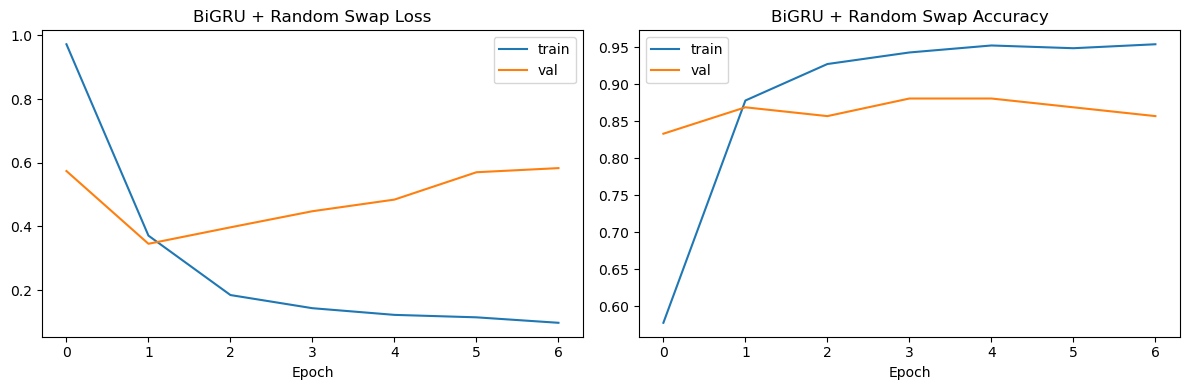

BiGRU + swap aug val: 0.858 test: 0.882


In [77]:
history_swap = gru_swap.fit(
    X_train_swap_pad, y_train_swap,
    validation_data=(X_val_pad, y_val),
    epochs=30, batch_size=32,
    class_weight=class_weight_dict_swap, verbose=1,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ModelCheckpoint('best_gru_swap_partB.h5', monitor='val_loss', save_best_only=True),
    ]
)

plot_history(history_swap, 'BiGRU + Random Swap')

f1_swap_val  = get_f1(gru_swap, X_val_pad,  y_val)
f1_swap_test = get_f1(gru_swap, X_test_pad, y_test)
print(f'BiGRU + swap aug val: {f1_swap_val:.3f} test: {f1_swap_test:.3f}')

### Swap Aug Findings
Random swap at 0.858 val landed below the sentence-split-only BiGRU at 0.883. This sits inside the K-fold range(BiGRU mean 0.844 ± 0.020, range 0.814 to 0.872), so random swap augmentation is not considered a real improvement. On a dataset this small, swapping word order in already-short reviews doesn't provide enough new signal to beat the baseline augmentation.

### Other Augmentation Techniques Considered
Other than sentence splitting and random swap, two more techniques were considered for this dataset:

- **Random deletion** (Wei & Zou, 2019): drops each word with some probability. Rejected because the EDA showed "didn't" and "tak" are critical negation words, and deletion can drop them, creating mislabeled training examples on a dataset that already has label noise. The median review is only 7 words, so dropping even one removes a meaningful fraction of the content.
- **Synonym replacement**: replace words with WordNet synonyms. Rejected for the same multilingual reason as lemmatization: WordNet is English only and would create an inconsistent pipeline between English and Malay rows.

# Analysis
Pick the best model across all experiments and run the full evaluation, error analysis, and results summary.

## Best Model Evaluation
Full evaluation runs only on the best model by val macro-F1. Confusion matrix and per-class precision, recall, and F1 show where the model succeeds and where it struggles.

In [78]:
# All candidate models keyed by name, each carrying its val F1 and the appropriate val/test data
best_candidates = {
    'SimpleRNN':(baseline, f1_baseline_val, X_val_pad, y_val, X_test_pad, y_test),
    'BiLSTM':(improved, f1_improved_val, X_val_pad, y_val, X_test_pad, y_test),
    'BiGRU':(gru_model, f1_gru_val, X_val_pad, y_val, X_test_pad, y_test),
    'BiLSTM_collapsed':(improved_c, f1_c_val, X_val_pad_c, y_val_c, X_test_pad_c, y_test_c),
    'BiGRU_collapsed':(gru_collapsed, f1_gru_c_val, X_val_pad_c, y_val_c, X_test_pad_c, y_test_c),
    'BiGRU_swap': (gru_swap, f1_swap_val, X_val_pad, y_val, X_test_pad, y_test),
    'BiGRU_fastText_frozen':(ft_frozen, f1_ft_frozen_val,X_val_pad, y_val, X_test_pad, y_test),
    'BiGRU_fastText_tuned': (ft_tuned, f1_ft_tuned_val, X_val_pad, y_val, X_test_pad, y_test)
}

best_name = max(best_candidates, key=lambda k: best_candidates[k][1])
best_obj, _, best_X_val, best_y_val, best_X_test, best_y_test = best_candidates[best_name]
print(f'Best model by val macro-F1: {best_name}')

Best model by val macro-F1: BiGRU


--- BiGRU Val ---
              precision    recall  f1-score   support

    negative       0.88      0.85      0.87        27
     neutral       0.86      0.82      0.84        22
    positive       0.92      0.97      0.94        35

    accuracy                           0.89        84
   macro avg       0.89      0.88      0.88        84
weighted avg       0.89      0.89      0.89        84



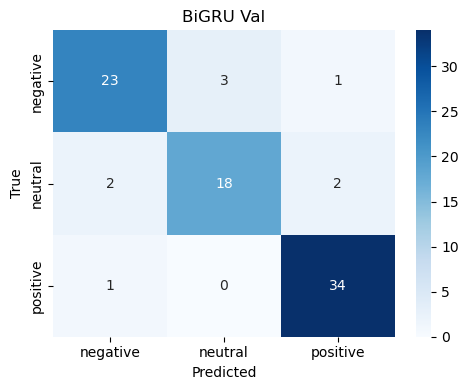

0.8831927583573043

In [79]:
evaluate(best_obj, best_X_val,  best_y_val, f'{best_name} Val')

--- BiGRU Test ---
              precision    recall  f1-score   support

    negative       0.92      0.92      0.92        24
     neutral       0.90      0.78      0.84        23
    positive       0.89      0.97      0.93        35

    accuracy                           0.90        82
   macro avg       0.90      0.89      0.90        82
weighted avg       0.90      0.90      0.90        82



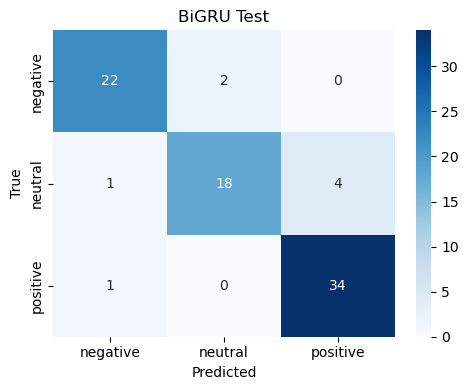

0.8951276061024389

In [80]:
evaluate(best_obj, best_X_test, best_y_test, f'{best_name} Test')

## Error Analysis
Misclassified reviews from the best model on the test set. Errors are grouped by true class to see which sentiment is hardest to predict correctly.

In [81]:
# Predict on test and find misclassifications
y_pred_best = best_obj.predict(best_X_test, verbose=0).argmax(axis=1)
errors = np.where(y_pred_best != best_y_test)[0]

label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}

# Pull raw text from the matching split (collapsed if best is a collapsed model)
best_X_raw = X_test_c if 'collapsed' in best_name else X_test

error_df = pd.DataFrame({
    'Review':best_X_raw[errors],
    'True':[label_map[l] for l in best_y_test[errors]],
    'Predicted':[label_map[l] for l in y_pred_best[errors]]
})

print(f'Total misclassified: {len(errors)} / {len(best_y_test)}')

Total misclassified: 8 / 82


In [82]:
print('Breakdown by true class:')
print(error_df['True'].value_counts().to_string())

Breakdown by true class:
True
neutral     5
negative    2
positive    1


In [83]:
print('Sample errors:')
for _, row in error_df.sample(min(10, len(error_df)), random_state=SEED).iterrows():
    print(f'[{row["True"]} -> {row["Predicted"]}] {row["Review"]}')

Sample errors:
[neutral -> positive] Felt like eating pizza at a hawker stall – smoky, spicy, and bold.
[negative -> neutral] Roti terlalu keras, kurang lembut.
[negative -> neutral] Wouldn't order again.
[neutral -> positive] Rasa pizza ni tidak terlalu kuat atau terlalu lemah. Boleh diterima untuk sekali makan. Tidak ada yang sangat istimewa.
[neutral -> negative] Too weird to love.
[neutral -> positive] A fair attempt at fusion pizza, but needs more balance.
[neutral -> positive] Unexpectedly delightful. Never thought I'd enjoy chili paste on pizza, but here we are. Satay adds heartiness. Mayo is a bit of a curveball. It's not traditional, but it is unforgettable. Great for foodies and risk-takers.
[positive -> negative] Pizza fusion ni buat saya rasa puas hati.


- Neutral is the hardest label with the most errors
- Mixed reviews like "Unexpectedly delightful. Never thought I'd enjoy chili paste on pizza, but here we are. Satay adds heartiness. Mayo is a bit of a curveball. It's not traditional, but it is unforgettable. Great for foodies and risk-takers.". Have positive words like delightful, enjoy (thus is predicted positive) but is labelled neutral overall.

## Results Summary
All architectures and dataset versions, ranked by val macro-F1.

In [84]:
# Final summary table covering every experiment
summary = {
    'Baseline SimpleRNN':(f1_baseline_val, f1_baseline_test),
    'BiLSTM (word)':(f1_improved_val, f1_improved_test),
    'BiGRU (word)':(f1_gru_val, f1_gru_test),
    'BiLSTM (collapsed)':(f1_c_val, f1_c_test),
    'BiGRU (collapsed)':(f1_gru_c_val, f1_gru_c_test),
    'BiGRU (swap aug)': (f1_swap_val, f1_swap_test),
    'BiGRU (fastText frozen)':(f1_ft_frozen_val, f1_ft_frozen_test),
    'BiGRU (fastText fine-tuned)':(f1_ft_tuned_val, f1_ft_tuned_test),
}

print(f'{"Model":<32} {"Val F1":>8} {"Test F1":>9}')
print('-' * 52)
for name, (val, test) in summary.items():
    print(f'{name:<32} {val:>8.3f} {test:>9.3f}')

best_val = max(summary, key=lambda k: summary[k][0])
print(f'\nBest by val: {best_val} ({summary[best_val][0]:.3f})')

Model                              Val F1   Test F1
----------------------------------------------------
Baseline SimpleRNN                  0.787     0.843
BiLSTM (word)                       0.865     0.894
BiGRU (word)                        0.883     0.895
BiLSTM (collapsed)                  0.823     0.907
BiGRU (collapsed)                   0.840     0.886
BiGRU (swap aug)                    0.858     0.882
BiGRU (fastText frozen)             0.754     0.833
BiGRU (fastText fine-tuned)         0.825     0.872

Best by val: BiGRU (word) (0.883)


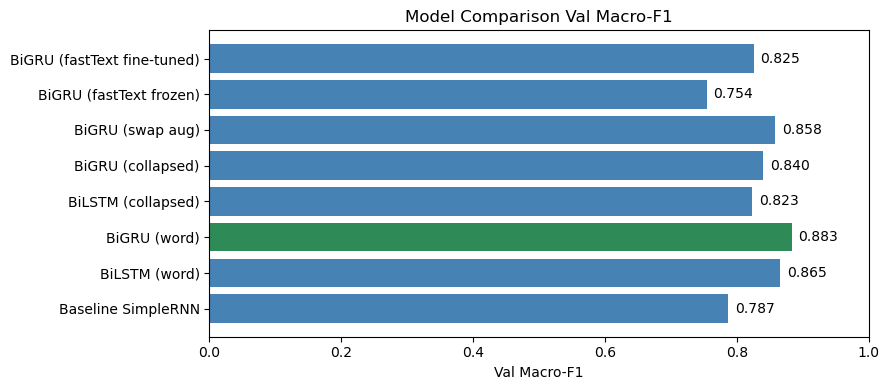

In [85]:
# Bar chart of val macro-F1 across all experiments
names = list(summary.keys())
vals = [v[0] for v in summary.values()]
colors = ['seagreen' if n == best_val else 'steelblue' for n in names]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(names, vals, color=colors)
ax.set_xlabel('Val Macro-F1')
ax.set_title('Model Comparison Val Macro-F1')
ax.set_xlim(0, 1)
for bar, v in zip(bars, vals):
    ax.text(v + 0.01, bar.get_y() + bar.get_height()/2, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

# Conclusion
After testing the different RNN layers, improving from baseline RNN to BiGRU increased macro F1 score from 0.787 to 0.883 on the validation set, and 0.843 to 0.895 on the test set.
- **Label Noise**: The label-noise dataset beat the collapsed version on both models: BiGRU 0.883 vs 0.840, BiLSTM 0.865 vs 0.823 on val. Keeping realistic noise gave the model more to learn from than artificially cleaning it.
- **Consistency Over Peak Performance**: BiGRU was selected as the best model after KFold cross validation due to its consistency. BiLSTM mean macro f1 was 0.015 higher (0.859 vs 0.844) but its standard deviation across folds (0.049) was more than double BiGRU's (0.020). BiLSTM swung from 0.775 to 0.913 across folds, a range of 0.138, while BiGRU stayed from 0.814 to 0.872 on every fold. On a small dataset, consistency is worth more than a 0.015 lead that ranges 0.138 across folds.
- **Context over Pretraining**: Using fastText embeddings did not help. Even when fine-tuned (0.825 val), it lost to the BiGRU trained from scratch (0.883). For specialized datasets, 700 highly relevant rows teach the model more than billions of generic web tokens, and context matters more than scale.
- **Quality Over Quantity**: Even though random word augmentation increased rows by ~2.7 times (893 to 2431), it failed to improve from the baseline. When reviews are already this short, mixing the words just breaks the natural context instead of helping the model learn.

## Save Best Model

In [87]:
best_obj.save('best_model_partB.h5')
print(f'Saved: {best_name} as best_model_partB.h5')

Saved: BiGRU as best_model_partB.h5
